# Kamień milowy 1

| Flux | AWIDNN |
|---|---|
| Flux.Conv | AWIDNN.Conv |
| Flux.MaxPool | AWIDNN.MaxPool |
| Flux.flatten / FlattenLayer | AWIDNN.flatten |
| Flux.Dense | AWIDNN.Dense |
| Flux.Dropout | AWIDNN.Dropout |
| Flux.Chain | AWIDNN.Chain |
| Flux.DataLoader | AWIDNN.DataLoader |
| Flux.logitcrossentropy | AWIDNN.logitcrossentropy |
| Flux.onehotbatch / Flux.onecold | AWIDNN.onehotbatch / AWIDNN.onecold |
| Flux.setup(Descent(η), model) | AWIDNN.setup(AWIDNN.Descent(η), graph) |
| Flux.gradient + Flux.update! | forward! * backward! * optimize! |
| Flux.trainmode! / testmode! | AWIDNN.trainmode! / AWIDNN.testmode! |

## Komórka 1 - dane + definicja sieci

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__)) # ponowna kompilacja biblioteki
using Random
Random.seed!(42) # powtarzalność tasowania i Dropoutu
using MLDatasets, AWIDNN

train_data = MLDatasets.FashionMNIST(split = :train)
test_data = MLDatasets.FashionMNIST(split = :test)

function loader(data; batchsize::Int = 1, shuffle::Bool = true)
    x4dim = reshape(Float32.(data.features), 28, 28, 1, :) # trywialny 4-wymiarowy kanał
    yhot = AWIDNN.onehotbatch(data.targets, 0:9) # 10 x N one-hot
    return AWIDNN.DataLoader((x4dim, yhot); batchsize, shuffle)
end

net = Chain(
    Conv((3, 3), 1 => 6,  pad = 1, bias = false), # 54 parametry
    MaxPool((2, 2)),
    Conv((3, 3), 6 => 16, pad = 1, bias = false), # 864 parametry
    MaxPool((2, 2)),
    # MaxPool((2, 2)), # przykład: dodatkowe poolowanie (7×7 → 3×3)
    flatten,
    Dense(784 => 84, relu), # 65_940 parametrów
    # Dense(144 => 84, relu), # 3×3×16 = 144 (wcześniej 7×7×16 = 784)
    Dropout(0.4),
    Dense(84 => 10), # 850 parametrów
)

  Activating project at `c:\Users\krzym\Documents\PW-Zadania\neural-network-practice`


Chain{Tuple{Conv{Float32, Array{Float32, 4}, Matrix{Float32}, typeof(identity)}, MaxPool{2}, Conv{Float32, Array{Float32, 4}, Matrix{Float32}, typeof(identity)}, MaxPool{2}, FlattenLayer, Dense{Float32, Matrix{Float32}, Matrix{Float32}, typeof(relu)}, Dropout, Dense{Float32, Matrix{Float32}, Matrix{Float32}, typeof(identity)}}}((Conv{Float32, Array{Float32, 4}, Matrix{Float32}, typeof(identity)}(Float32[0.2627852 -0.24441832 -0.3043078; -0.2932862 -0.23406507 0.21054028; -0.2912645 -0.024193956 0.4795611;;;; -0.11805662 -0.19779836 0.043046404; 0.26537564 0.14320213 -0.09825797; -0.3917904 0.3174428 -0.12475615;;;; 0.38983727 0.37796652 0.072800435; 0.085616164 0.09659613 -0.20303863; 0.06697503 -0.5102797 0.21631579;;;; 0.44528982 0.26949725 -0.10358129; -0.22197352 -0.12691526 -0.013491134; -0.33519933 -0.068871036 0.0349236;;;; -0.32183015 0.13472514 0.48669216; 0.32188693 0.3993199 -0.012467011; 0.4370058 -0.40969622 -0.23864578;;;; -0.3196763 -0.085786946 0.17566466; 0.31828177 -0

## Komórka 2 - ewaluacja + ustawienia treningu

In [2]:
function loss_and_accuracy(model, data; batchsize::Int = 100)
    testmode!(model) # Dropout w trybie ewaluacji (identyczność, bez losowania maski)
    dl = loader(data; batchsize = batchsize, shuffle = false) # stała kolejność batchy (powtarzalność metryki)
    total_loss, total_correct, total = 0f0, 0, 0 # akumulatory: suma ważonej straty, liczba trafień, liczba próbek
    for (x, y) in dl # "x": obrazy batcha, "y": wektory etykiet (ostatni wymiar = batch)
        input = Constant(x) # liść grafu: wejście (nietrenowalne; tylko forward używa "input.output")
        target = Constant(y) # liść grafu: prawdziwe etykiety (one-hot)
        ŷ_node = model(input) # budowa grafu: od wejścia do surowych wyników (ostatni węzeł = wyjście sieci)
        L_node = AWIDNN.logitcrossentropy(ŷ_node, target) # skalarna strata CE na batchu (średnia po batchu wewnątrz operatora)
        g = graph(L_node) # porządek topologiczny węzłów od liści do korzenia = "L_node"
        forward!(g) # oblicza wszystkie "output" operatorów; "L_node.output" = wartość straty na tym batchu
        bs = size(x)[end] # rozmiar batcha (ostatnia oś = próbki)
        total_loss += L_node.output * bs # suma ważona: strata jest średnią po batchu, więc mnożna przemnożyć przez rozmiar batcha żeby dostać sumę po próbkach
        total_correct += sum(AWIDNN.onecold(ŷ_node.output) .== AWIDNN.onecold(target.output)) # ilość prognoz (argmax logitów(wyników sieci)) zgadzających się z etykietą
        total += bs # ilość policzonych próbek (do średniej ważonej straty i % dokładności)
    end
    trainmode!(model, true) # po ewaluacji ustawia tryb treningowy (Dropout znów losuje maskę)
    return (; loss  = total_loss / total, acc   = round(100 * total_correct / total; digits = 2), split = data.split) # NamedTuple: średnia strata, dokładność [%], etykieta zbioru (:train/:test)
end

@show loss_and_accuracy(net, test_data) # ~10% dokładności oznacza losowy model przed treningiem

train_log = []
settings = (;
    eta = 1f-2, 
    epochs = 3, 
    batchsize = 10,
)
opt = AWIDNN.Descent(settings.eta)
opt_state = nothing # graf jest budowany w komórce 3 i wtedy wywołuje setup

loss_and_accuracy(net, test_data) = (loss = 2.3274786f0, acc = 10.36, split = :test)


## Komórka 3 - pętla treningu

In [3]:
input   = Constant(zeros(Float32, 28, 28, 1, settings.batchsize)) # bufor wejścia: kształt jak batch obrazów; zawartość nadpisywana w pętli ("input.output .= x")
target  = Constant(zeros(Float32, 10, settings.batchsize)) # bufor wektora etykiet (10 klas x batch); nadpisywany w pętli ("target.output .= y")
trainmode!(net, true) # Dropout w trybie treningu (losowanie maski)
ŷ_node  = net(input) # budowa grafu: topologia sieci stała, zmieniają się tylko dane w "Constant"
L_node  = AWIDNN.logitcrossentropy(ŷ_node, target) # korzeń grafu = skalarna strata na batchu (używana w "backward!")
g_train = graph(L_node) # lista węzłów w porządku topologicznym (liście -> korzeń); ta sama kolejność w każdej iteracji
opt_state = AWIDNN.setup(opt, g_train) # stan optymalizatora: "(Descent(η), g_train)" do "update!" po "backward!"

accuracy = zeros(settings.epochs, 2) # kolumna 1 = train, 2 = test
for epoch in 1:settings.epochs
    @time for (x, y) in loader(train_data; batchsize = settings.batchsize, shuffle = true)
        size(x)[end] == settings.batchsize || continue # pominięcie krótrzego batcha (może być on ostatni)
        input.output  .= x # podmiana danych bez przebudowy grafu
        target.output .= y
        forward!(g_train) # liczenie yhat i straty
        backward!(g_train) # gradienty w .gradient przy Variable
        AWIDNN.update!(opt_state) # krok SGD (wagi -= η * grad)
    end

    tr = loss_and_accuracy(net, train_data) # strata i dokładność na train (testmode na czas liczenia, na końcu z powrotem train)
    te = loss_and_accuracy(net, test_data)
    @info epoch tr.acc te.acc
    push!(train_log, (; epoch, tr_loss = tr.loss, tr_acc = tr.acc, te_loss = te.loss, te_acc = te.acc)) # zapis do wektora
    accuracy[epoch, 1] = tr.acc # wiersz = epoka, kolumny: train / test
    accuracy[epoch, 2] = te.acc
    trainmode!(net, true) # na wszelki wypadek przed kolejną epoką (Dropout z powrotem na "trainmode")
end

 16.357351 seconds (15.76 M allocations: 996.217 MiB, 1.56% gc time, 29.08% compilation time)


┌ Info: 1
│   tr.acc = 84.88
└   te.acc = 83.95


 11.270233 seconds (2.29 M allocations: 323.102 MiB, 0.08% gc time)


┌ Info: 2
│   tr.acc = 87.19
└   te.acc = 86.04


 11.259983 seconds (2.29 M allocations: 323.102 MiB, 0.07% gc time)


┌ Info: 3
│   tr.acc = 88.92
└   te.acc = 87.5


## Komórka 4 - krzywe dokładności

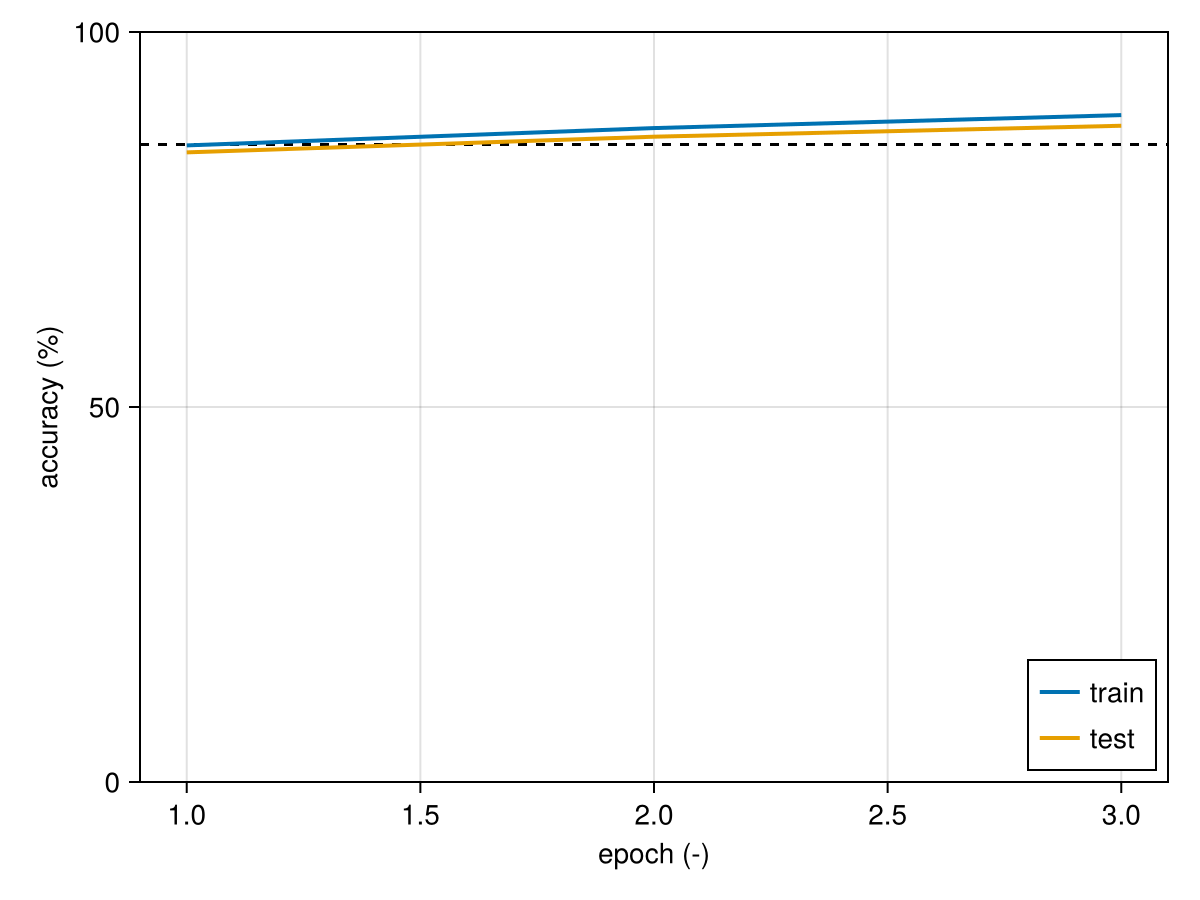

In [4]:
using CairoMakie
fig = Figure()
gca = Axis(fig[1, 1], xlabel = "epoch (-)", ylabel = "accuracy (%)")
hlines!(85, linestyle = :dash, color = :black)
lines!(gca, accuracy[:, 1], linewidth = 2, label = "train")
lines!(gca, accuracy[:, 2], linewidth = 2, label = "test")
ylims!(gca, (0, 100))
axislegend(gca, position = :rb)
fig

## Komórka 5 - ewaluacja końcowa + pogląd na próbkę

In [5]:
x1, y1 = first(loader(test_data; batchsize = 1, shuffle = false))
testmode!(net)
input.output  .= x1
target.output .= y1
forward!(g_train)
@show hcat(AWIDNN.onecold(ŷ_node.output, 0:9), AWIDNN.onecold(target.output, 0:9))
@show loss_and_accuracy(net, test_data)

hcat(AWIDNN.onecold(ŷ_node.output, 0:9), AWIDNN.onecold(target.output, 0:9)) = [9 9; 9 9; 9 9; 9 9; 9 9; 9 9; 9 9; 9 9; 9 9; 9 9]
loss_and_accuracy(net, test_data) = (loss = 0.3411828f0, acc = 87.5, split = :test)


(loss = 0.3411828f0, acc = 87.5, split = :test)

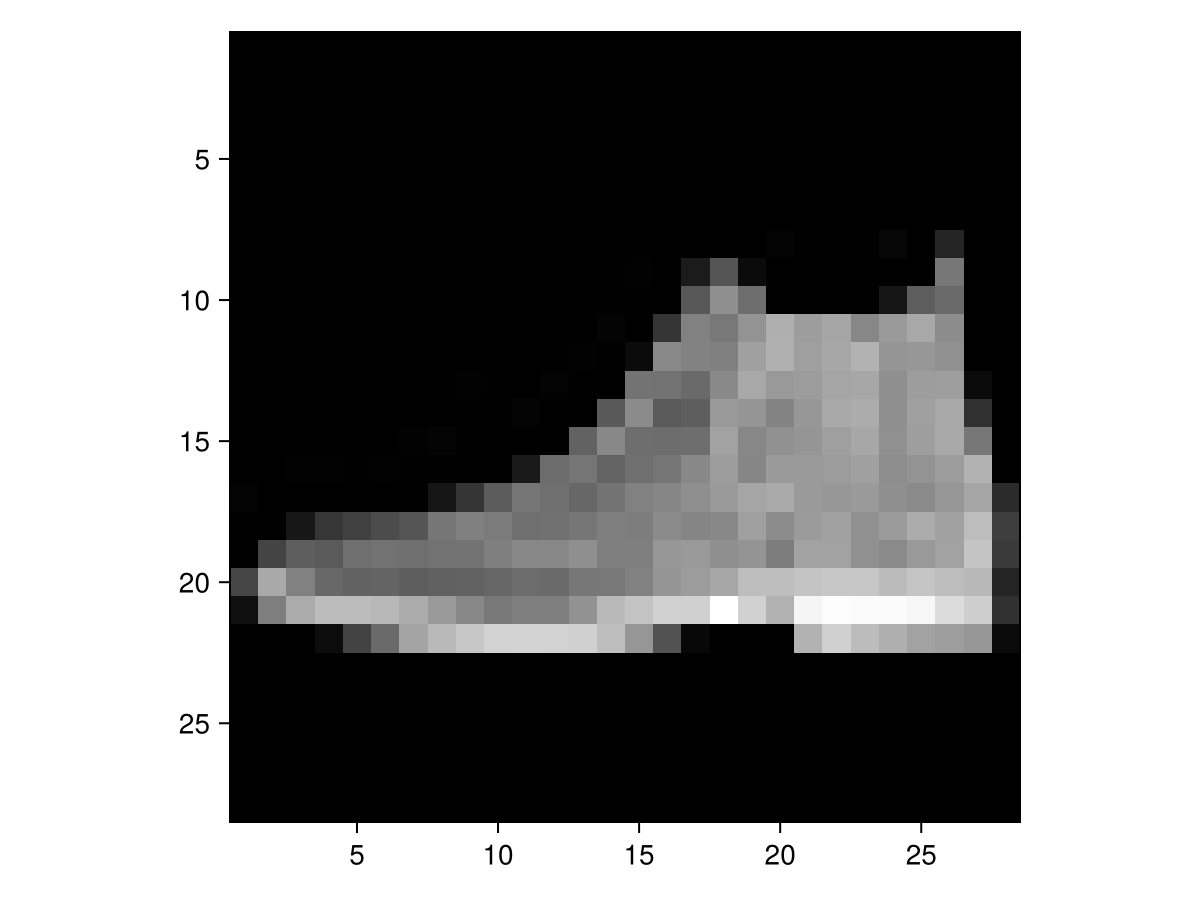

In [6]:
heatmap(x1[:, :, 1, 1], colormap = :bone,
        axis = (aspect = DataAspect(), yreversed = true))